# Matrix-Making Notebook

The purpose of this notebook is to create matrix-like figures that summarize accuracy of the model across various experiments run in climate_experiments.ipynb.

### Imports and File Stitching

In [102]:
# General Imports
import pandas as pd
import numpy as np
import os
import sys
import glob
import string

# Combinations
from itertools import combinations

# Plotting
import matplotlib.pyplot as plt

# ----File Stitching----
# If in climate_experiments folder, cd back to MamalakisResearch folder
if os.path.basename(os.getcwd()) == "climate_experiments":
    os.chdir('..')
# If a file is in /data_prep_viz/prep/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), '..', 'data_prep_viz/prep'))

### Read Files

In [103]:
# Read csv files
summary_1 = pd.read_csv("climate_experiments/experiment_summary_ck_1.csv")
summary_2 = pd.read_csv("climate_experiments/experiment_summary_ck_2.csv")
# ^ Make into a for loop eventually
summaries = [summary_1, summary_2]

In [104]:
# Read all csv files in climate_experiments folder
path = os.getcwd() + '/climate_experiments/'
csvs = glob.glob(os.path.join(path, "*.csv"))
summaries = []
for csv in csvs:
    df = pd.read_csv(csv)
    summaries.append(df)

### Calculations

In [105]:
# Calculate mean and standard deviation of accuracy between runs of the same experiment
def get_mean_std(summaries):
    # Make a df to hold: 
    # a) metadata
    acc_df = pd.DataFrame(columns=['scenario','early', 'late'])
    acc_df['scenario'] = summaries[0]['scenario']
    acc_df['early'] = summaries[0]['early']
    acc_df['late'] = summaries[0]['late']
    
    # b) accuracies
    for i in range(len(csvs)-1):
        acc_df[f"acc_{i}"] = summaries[i]['mean_pred']  ## Change to accuracy
    
    # c) mean and std
    acc_cols = [col for col in acc_df.columns if col.startswith('acc_')]
    acc_df['mean'] = acc_df[acc_cols].mean(axis=1)
    acc_df['std'] = acc_df[acc_cols].std(axis=1)
    
    return acc_df

In [106]:
mean_std = get_mean_std(summaries)
mean_std.head()

,scenario,early,late,acc_0,acc_1,acc_2,mean,std
0,ssp119,2015,2025,0.488683,0.590495,0.397542,0.492240,0.096526
1,ssp119,2015,2035,0.590137,0.511218,0.501518,0.534291,0.048607
2,ssp119,2015,2045,0.487564,0.563199,0.507156,0.519306,0.039254
3,ssp119,2015,2055,0.738778,0.470238,0.510707,0.573241,0.144780
4,ssp119,2015,2065,0.459767,0.489292,0.478718,0.475926,0.014959


### Making a Matrix

In [107]:
# Make a copy
mean_std = mean_std.copy()
# Create the label pairings by changing scenario-early-late to a single, concatenated index
mean_std['label'] = mean_std['scenario'] + '_' + mean_std['early'].astype(str) + '_' + mean_std['late'].astype(str)
mean_std = mean_std.drop(columns=['scenario', 'early', 'late'])
# Drop the acc columns
mean_std = mean_std.drop(columns=[col for col in mean_std.columns if col.startswith('acc_')])
mean_std.set_index('label', inplace=True)
mean_std_119 = mean_std.filter(like='119', axis=0)
mean_std_126 = mean_std.filter(like='126', axis=0)
mean_std_119.head()

,mean,std
label,,
ssp119_2015_2025,0.492240,0.096526
ssp119_2015_2035,0.534291,0.048607
ssp119_2015_2045,0.519306,0.039254
ssp119_2015_2055,0.573241,0.144780
ssp119_2015_2065,0.475926,0.014959


Source - https://stackoverflow.com/a/66823998

Posted by Max Pierini, modified by community. See post 'Timeline' for change history

Retrieved 2026-04-13, License - CC BY-SA 4.0

In [108]:
def turn_into_matrix_df(mean_std_scenario):
    values = [a - b for a, b in combinations(mean_std_scenario['mean'], 2)]
    index = [f"{a} vs {b}" for a, b in combinations(mean_std_scenario.index, 2)]
    sr = pd.Series(values, index = index)
    
    df = sr.reset_index()
    df.columns = ['row_col', 'data']

    # Add missing values, will leave blank when actually plotting
    df_inv = pd.DataFrame({
        'row_col': [f"{b} vs {a}" for a, b in combinations(mean_std_scenario.index, 2)],
        'data': df.data * -1
        })
    
    df_values = pd.concat([df,df_inv])
    df_values[['row', 'col']] = df_values.row_col.str.split(' vs ', expand=True)

    # Source - https://stackoverflow.com/a/66823998
# Posted by Max Pierini, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-13, License - CC BY-SA 4.0

    df_piv = df_values[['row', 'col', 'data']].pivot(index='row', columns='col').fillna(0).astype(float)


    return df_piv

df_119 = turn_into_matrix_df(mean_std_119)
df_126 = turn_into_matrix_df(mean_std_126)
df_119.head()

data                                    \
col              ssp119_2015_2025 ssp119_2015_2035 ssp119_2015_2045   
row                                                                   
ssp119_2015_2025         0.000000        -0.042051        -0.027066   
ssp119_2015_2035         0.042051         0.000000         0.014985   
ssp119_2015_2045         0.027066        -0.014985         0.000000   
ssp119_2015_2055         0.081001         0.038950         0.053935   
ssp119_2015_2065        -0.016315        -0.058365        -0.043381   

                                                                     \
col              ssp119_2015_2055 ssp119_2015_2065 ssp119_2015_2075   
row                                                                   
ssp119_2015_2025        -0.081001         0.016315        -0.024925   
ssp119_2015_2035        -0.038950         0.058365         0.017126   
ssp119_2015_2045        -0.053935         0.043381         0.002141   
ssp119_2015_2055         0.000000         0.097316         0.056076   
ssp119_2015_2065        -0.097316         0.000000        -0.041240   

                                                                     \
col              ssp119_2015_2085 ssp119_2025_2035 ssp119_2025_2045   
row                                                                   
ssp119_2015_2025        -0.007525        -0.081053         0.006513   
ssp119_2015_2035         0.034526        -0.039002         0.048564   
ssp119_2015_2045         0.019541        -0.053987         0.033580   
ssp119_2015_2055         0.073476        -0.000052         0.087514   
ssp119_2015_2065        -0.023840        -0.097368        -0.009801   

                                   ...                                    \
col              ssp119_2025_2055  ... ssp119_2035_2085 ssp119_2045_2055   
row                                ...                                     
ssp119_2015_2025        -0.001759  ...        -0.041399        -0.060542   
ssp119_2015_2035         0.040292  ...         0.000652        -0.018492   
ssp119_2015_2045         0.025307  ...        -0.014333        -0.033476   
ssp119_2015_2055         0.079242  ...         0.039602         0.020459   
ssp119_2015_2065        -0.018074  ...        -0.057713        -0.076857   

                                                                     \
col              ssp119_2045_2065 ssp119_2045_2075 ssp119_2045_2085   
row                                                                   
ssp119_2015_2025        -0.067922         0.059287         0.006241   
ssp119_2015_2035        -0.025871         0.101338         0.048292   
ssp119_2015_2045        -0.040855         0.086353         0.033307   
ssp119_2015_2055         0.013079         0.140288         0.087242   
ssp119_2015_2065        -0.084236         0.042972        -0.010074   

                                                                     \
col              ssp119_2055_2065 ssp119_2055_2075 ssp119_2055_2085   
row                                                                   
ssp119_2015_2025        -0.008648        -0.031777        -0.015539   
ssp119_2015_2035         0.033403         0.010274         0.026512   
ssp119_2015_2045         0.018418        -0.004711         0.011528   
ssp119_2015_2055         0.072353         0.049224         0.065462   
ssp119_2015_2065        -0.024963        -0.048092        -0.031853   

                                                    
col              ssp119_2065_2075 ssp119_2065_2085  
row                                                 
ssp119_2015_2025        -0.013366        -0.024114  
ssp119_2015_2035         0.028685         0.017937  
ssp119_2015_2045         0.013701         0.002952  
ssp119_2015_2055         0.067636         0.056887  
ssp119_2015_2065        -0.029680        -0.040429  

[5 rows x 27 columns]

C:\Users\student\AppData\Local\Temp\ipykernel_54128\2229301666.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['']+labels)
C:\Users\student\AppData\Local\Temp\ipykernel_54128\2229301666.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['']+labels)


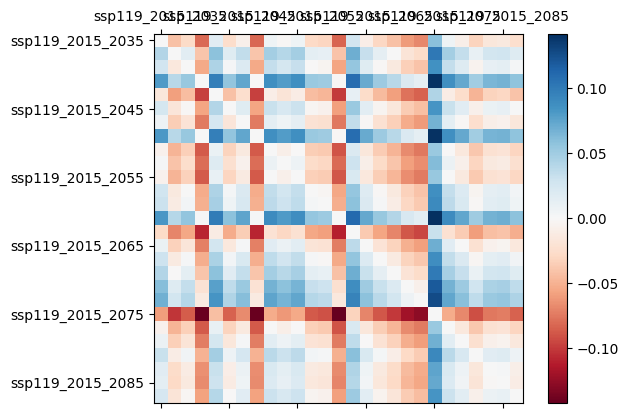

In [111]:
# Function to plot with colors and labels
def matshow_plot(df):
    labels = df.index
    data = df
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(data, interpolation='nearest', cmap='RdBu', vmin=-np.max(np.abs(data.values)), vmax=np.max(np.abs(data.values)))    
    fig.colorbar(cax)
    ax.set_xticklabels(['']+labels)
    ax.set_yticklabels(['']+labels)

    plt.show()

matshow_plot(df_119)


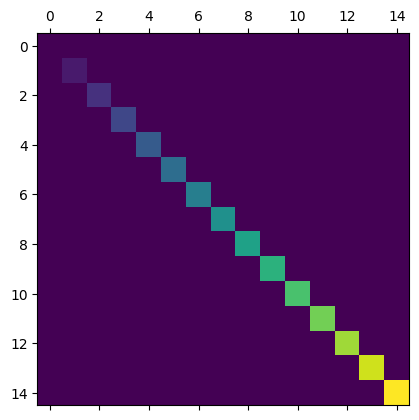

In [110]:
import matplotlib.pyplot as plt
import numpy as np

# a 2D array with linearly increasing values on the diagonal
a = np.diag(range(15))

plt.matshow(a)

plt.show()